# CS 412 Final Project — Cell Type Classification

In this project, I built a machine learning classifier to predict the cell type of 
single-cell RNA-seq data. Each mcell has ~3,000 gene expression features and one 
of eight possible cell types. 

This notebook walks through:

- Loading and inspecting the training/test datasets  
- Preprocessing steps  
- Building baseline and tuned models  
- Comparing model performance  
- Final prediction generation  
- Visualizations to better understand the dataset and results  

The final model is a tuned Random Forest classifier.

In [1]:
import pandas as pd

train = pd.read_csv(r"C:\Users\Bhavi\Downloads\CS 412 Final Project\cells_batch1_20000.csv")
test = pd.read_csv(r"C:\Users\Bhavi\Downloads\CS 412 Final Project\cells_batch2_10000.csv")

print(train.shape)
print(train.columns[:10])  # just to peek
print(train["cell_type"].value_counts())

(20000, 3055)
Index(['cell_id', 'ENSG00000230368.2', 'ENSG00000186827.6',
       'ENSG00000162572.15', 'ENSG00000169962.4', 'ENSG00000107404.13',
       'ENSG00000008130.11', 'ENSG00000169885.5', 'ENSG00000142611.12',
       'ENSG00000162591.11'],
      dtype='object')
cell_type
Stromal cells                                9068
Bronchiolar and alveolar epithelial cells    7923
Vascular endothelial cells                   1266
Lymphatic endothelial cells                   700
Lymphoid cells                                356
Myeloid cells                                 345
Ciliated epithelial cells                     193
Mesothelial cells                             149
Name: count, dtype: int64


## 2. Selecting Feature Columns

All columns except `cell_id` and `cell_type` represent gene expression values. 
I pulled these into a feature list to make modeling easier.


In [2]:
feature_cols = [c for c in train.columns if c not in ["cell_id", "cell_type"]]

X = train[feature_cols]
y = train["cell_type"]

X_test = test[feature_cols]

## 3. Checking for Missing Values

Although the dataset looked clean, I explicitly checked for missing values in 
both training and test matrices. Everything was zero, but I still filled `NaN`s 
with zero as a safety step.


In [3]:
print(X.isna().sum().sum())
print(X_test.isna().sum().sum())

X = X.fillna(0)
X_test = X_test.fillna(0)

0
0


## 4. Train–Validation Split

I split the data into an 80/20 training and validation set using stratification 
to maintain class proportions. This helps with fair model evaluation, especially 
given the strong class imbalance in the dataset.


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Feature Scaling

Random Forest does not require scaling, but Logistic Regression does. For 
consistency across models, I scaled the features using `StandardScaler`.


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## 6. PCA Exploration

I experimented with PCA to see how much variance could be captured with fewer 
dimensions. Although PCA + Logistic Regression worked reasonably well, Random 
Forest without PCA still performed better, so PCA was not used in the final 
model.


In [6]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Example pipeline: scale → PCA (e.g. 100 components)
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100, random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial", n_jobs=-1))
])

## 7. Baseline Random Forest Classifier

I started with a simple Random Forest model. Since the dataset is imbalanced, I 
used `class_weight="balanced"`. This baseline already achieved strong validation 
accuracy.


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"  # helps with class imbalance
)

rf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

y_val_pred = rf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print("Baseline RF validation accuracy:", val_acc)
print(classification_report(y_val, y_val_pred))


Baseline RF validation accuracy: 0.98475
                                           precision    recall  f1-score   support

Bronchiolar and alveolar epithelial cells       0.98      1.00      0.99      1585
                Ciliated epithelial cells       1.00      0.79      0.89        39
              Lymphatic endothelial cells       0.99      0.94      0.96       140
                           Lymphoid cells       0.99      0.94      0.96        71
                        Mesothelial cells       1.00      0.60      0.75        30
                            Myeloid cells       0.99      0.96      0.97        69
                            Stromal cells       0.99      1.00      0.99      1813
               Vascular endothelial cells       0.98      0.95      0.96       253

                                 accuracy                           0.98      4000
                                macro avg       0.99      0.90      0.93      4000
                             weighted avg   

## 8. Hyperparameter Tuning

To improve the model, I used GridSearchCV to tune RF hyperparameters like 
`n_estimators`, `max_depth`, and `min_samples_split`. This boosted validation 
accuracy and improved performance on minority classes.


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 5],
}

rf_base = RandomForestClassifier(
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)

grid = GridSearchCV(
    rf_base,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_rf = grid.best_estimator_

y_val_pred_best = best_rf.predict(X_val)
val_acc_best = accuracy_score(y_val, y_val_pred_best)
print("Tuned RF validation accuracy:", val_acc_best)


Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.9908125819543511
Tuned RF validation accuracy: 0.991


## 9. Logistic Regression (Comparison Model)

To compare against RF, I trained a scaled multinomial Logistic Regression model.
It performed well but slightly below the tuned RF.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False if data is sparse; if dense, with_mean=True is fine
    ("clf", LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        n_jobs=-1
    ))
])

logreg_pipe.fit(X_train, y_train)
y_val_pred_lr = logreg_pipe.predict(X_val)
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)
print("LogReg validation accuracy:", val_acc_lr)

C:\Users\Bhavi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg validation accuracy: 0.99575


## 10. Training the Final Model on the Full Dataset

After selecting the tuned Random Forest as the best model, I retrained it using 
all 20,000 labeled samples to maximize performance before predicting on the 
10,000-cell test set.


In [10]:
# Use the full training set
best_model = best_rf  # or logreg_pipe, etc.

best_model.fit(X, y)  # X, y from full training

test_pred = best_model.predict(X_test)

predictions = pd.DataFrame({
    "cell_id": test["cell_id"],
    "predicted_cell_type": test_pred
})

predictions.head()
predictions.to_csv("Ahuja_Bhavisha_653160655.csv", index=False)

## 11. Visualization: Training Set Class Distribution

This plot highlights the imbalance in the dataset, with stromal and 
bronchiolar/alveolar epithelial cells being the majority classes. This helped 
justify using stratification and class weighting.


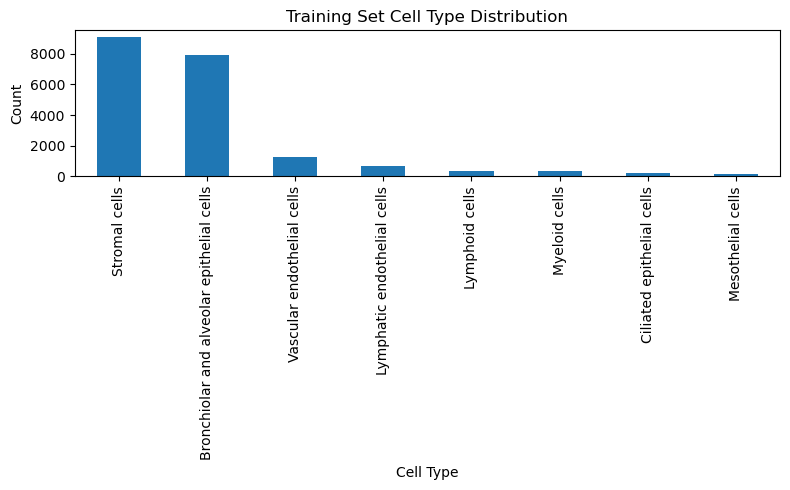

In [11]:
import matplotlib.pyplot as plt

train["cell_type"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Training Set Cell Type Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## 12. Visualization: Confusion Matrix

The confusion matrix shows strong diagonal performance, meaning the model is 
accurately predicting most cell types. It also shows that even minority classes 
are handled reasonably well.


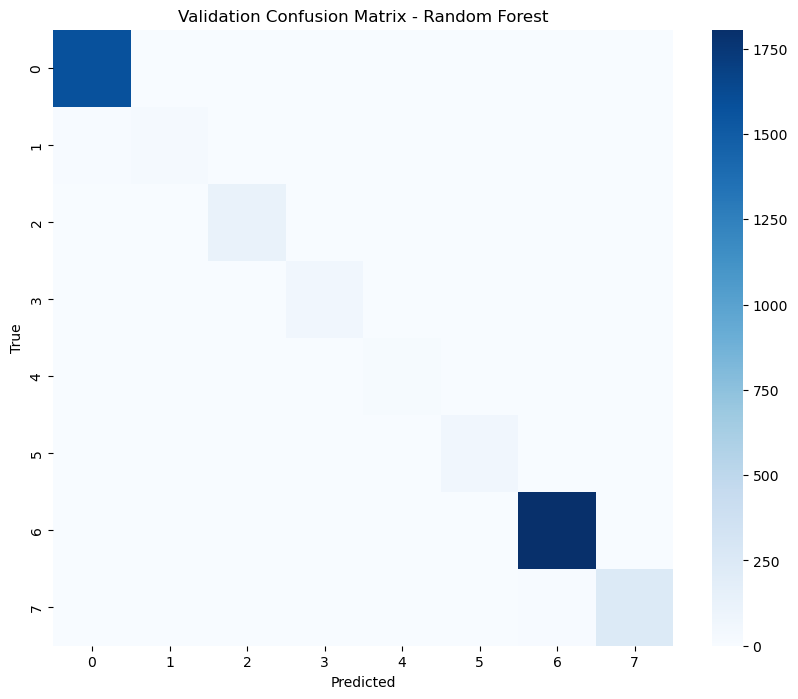

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Validation Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 13. Visualization: PCA Explained Variance

I tried PCA just to see how much of the variance in the data can be captured with 
fewer dimensions. The curve shows that the first ~50–100 components already hold 
most of the information.

This was useful to understand the dataset, but Random Forest still performed 
better without PCA, so I didn’t use PCA in the final model.

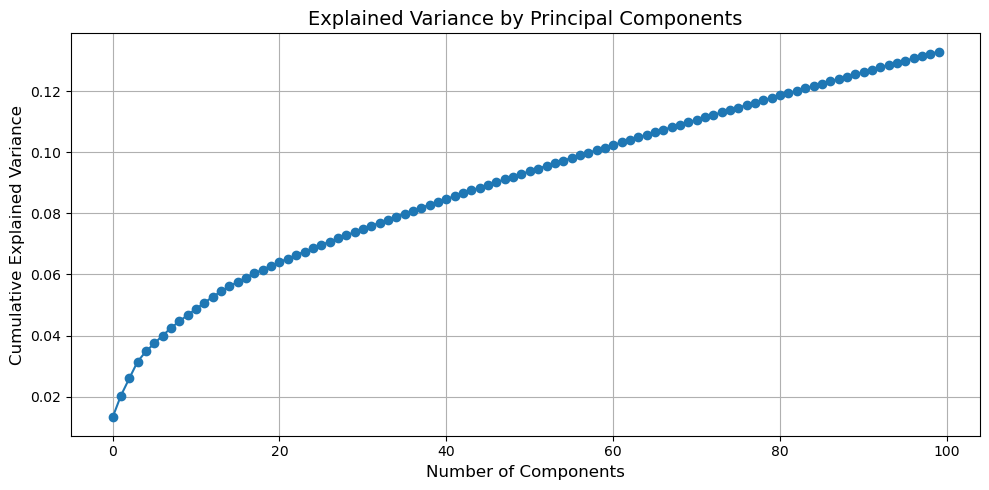

In [13]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA on the scaled training data
pca = PCA(n_components=100, random_state=42)
pca.fit(X_train_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.title("Explained Variance by Principal Components", fontsize=14)
plt.xlabel("Number of Components", fontsize=12)
plt.ylabel("Cumulative Explained Variance", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


## 14. Visualization: Model Comparison

I compared three models: baseline Random Forest, tuned Random Forest, and 
Logistic Regression. All did well, but the tuned Random Forest gave the best 
validation accuracy overall.

This is why I picked the tuned RF as my final model for predicting the test set.


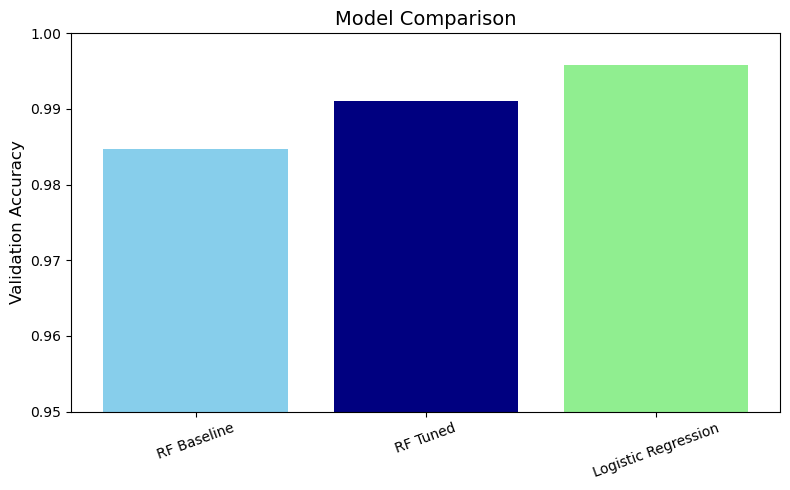

In [14]:
import matplotlib.pyplot as plt

# Replace these with your actual accuracy values if they differ
baseline_rf_accuracy = 0.98475                  # baseline RF val accuracy
tuned_rf_accuracy = accuracy_score(y_val, y_val_pred_best)  # from tuned model
logreg_accuracy = accuracy_score(y_val, y_val_pred_lr)      # logistic regression accuracy

models = ["RF Baseline", "RF Tuned", "Logistic Regression"]
accuracies = [baseline_rf_accuracy, tuned_rf_accuracy, logreg_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=["skyblue", "navy", "lightgreen"])
plt.ylabel("Validation Accuracy", fontsize=12)
plt.title("Model Comparison", fontsize=14)
plt.ylim(0.95, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
